# Trabalho Final - Predição de Diabetes (Pima Indians)

**Disciplina de Inteligência Artificial , Professor Munif , Unicesumar 2026**

## Integrantes
- Pedro Henrique da Silva - RA: 23021607-2
- Victor Hugo Rodrigues de Oliveira - RA: 23418156-2
- Victor Hungo Silva Garcia - RA: 23030968-2

## Contextualização
O diabetes mellitus é uma doença crônica que afeta milhões de pessoas no mundo. A detecção precoce é fundamental para reduzir complicações. Este notebook aplica **KNN** (Parte 1) e **SVM** (Parte 2) para prever diabetes com o dataset **Pima Indians**.

> **Como executar:** menu *Runtime → Run all* (ou Ctrl+F9)

In [1]:
import os
import sys
from pathlib import Path

REPO_URL = "https://github.com/PedroSilvazDev/trabalho-final-ia-diabetes-colab.git"
REPO_DIR = "trabalho-final-ia-diabetes-colab"

if Path("src").exists():
    root = Path.cwd()
elif Path(REPO_DIR, "src").exists():
    os.chdir(REPO_DIR)
    root = Path.cwd()
else:
    !git clone {REPO_URL}
    os.chdir(REPO_DIR)
    root = Path.cwd()

sys.path.insert(0, str(root))
!pip install -q -r requirements.txt

print("Diretorio:", root)

Cloning into 'trabalho-final-ia-diabetes-colab'...
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 15 (delta 0), reused 15 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (15/15), 7.73 KiB | 2.58 MiB/s, done.
Diretorio: /content/trabalho-final-ia-diabetes-colab


## 1. Carregar dataset

| Item | Descrição |
|------|-----------|
| Nome | Pima Indians Diabetes Database |
| Origem | Kaggle / UCI ML Repository |
| Registros | 768 amostras |
| Variável alvo | Outcome (0 = sem diabetes, 1 = com diabetes) |

In [2]:
import pandas as pd
from IPython.display import display

from src.data_loader import load_dataset

df = load_dataset()
print(f"Registros: {len(df)} | Atributos: {df.shape[1] - 1}")
print("\nDistribuicao da variavel alvo:")
print(df["Outcome"].value_counts())
display(df.head())

Baixando dataset de https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv ...
Dataset salvo em /content/trabalho-final-ia-diabetes-colab/data/diabetes.csv
Registros: 768 | Atributos: 8

Distribuicao da variavel alvo:
Outcome
0    500
1    268
Name: count, dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Preparação dos dados

- Substituição de zeros inválidos por valores ausentes
- Imputação pela mediana
- Padronização (StandardScaler)
- Divisão estratificada 80% treino / 20% teste

In [3]:
from src.preprocess import prepare_data

prepared = prepare_data(df)
print(f"Treino: {len(prepared.y_train)} amostras")
print(f"Teste: {len(prepared.y_test)} amostras")

Treino: 614 amostras
Teste: 154 amostras


## 3. Treinamento - KNN (Parte 1)

In [4]:
from src.train import train_knn, print_result_summary

knn_result = train_knn(prepared)
print_result_summary(knn_result, prepared)


=== KNN ===
Melhores hiperparametros: {'n_neighbors': 13}
Acuracia no treino: 0.8062
Acuracia no teste: 0.7143
Precisao: 0.6087
Revocacao: 0.5185
F1-score: 0.5600
ROC-AUC: 0.7944


## 4. Treinamento - SVM (Parte 2)

In [5]:
from src.train import train_svm

svm_result = train_svm(prepared)
print_result_summary(svm_result, prepared)


=== SVM ===
Melhores hiperparametros: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Acuracia no treino: 0.7866
Acuracia no teste: 0.7013
Precisao: 0.5909
Revocacao: 0.4815
F1-score: 0.5306
ROC-AUC: 0.8131


## 5. Avaliação e comparação

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

from src.evaluate import (
    plot_confusion_matrix,
    plot_knn_k_search,
    plot_metrics_comparison,
    plot_roc_curves,
)

%matplotlib inline

metrics_df = pd.DataFrame([
    {"modelo": "KNN", **knn_result.metrics},
    {"modelo": "SVM", **svm_result.metrics},
])

display(metrics_df)

,modelo,accuracy,precision,recall,f1_score,roc_auc
0,KNN,0.714286,0.608696,0.518519,0.560000,0.794444
1,SVM,0.701299,0.590909,0.481481,0.530612,0.813148


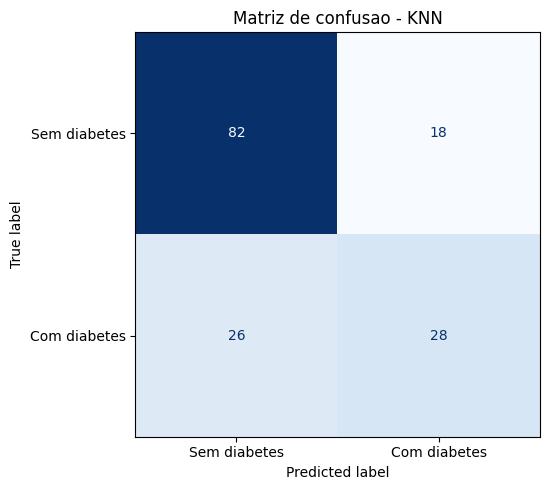

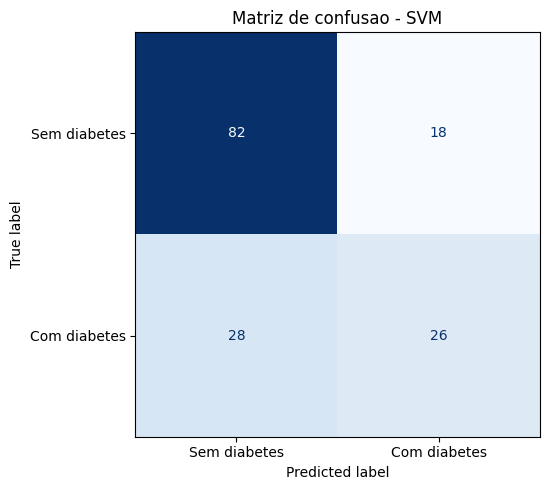

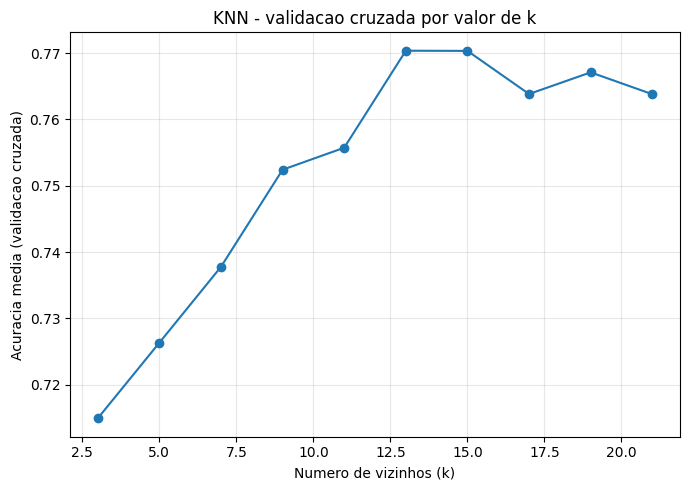

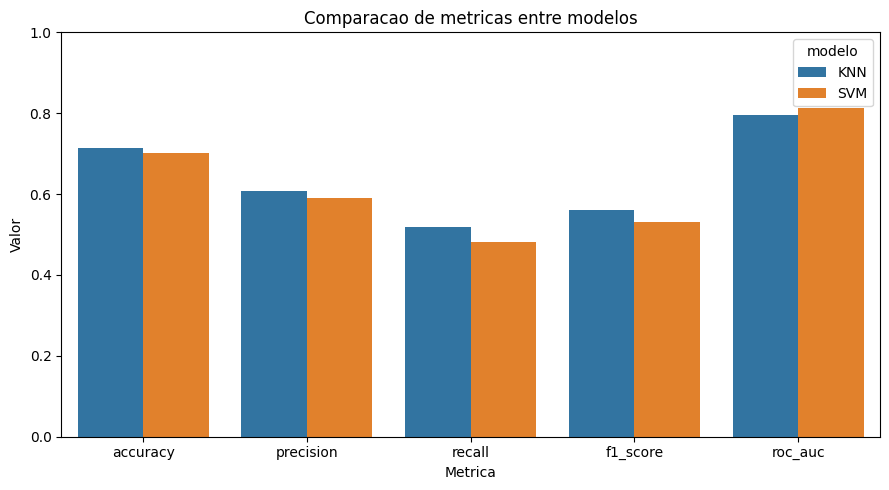

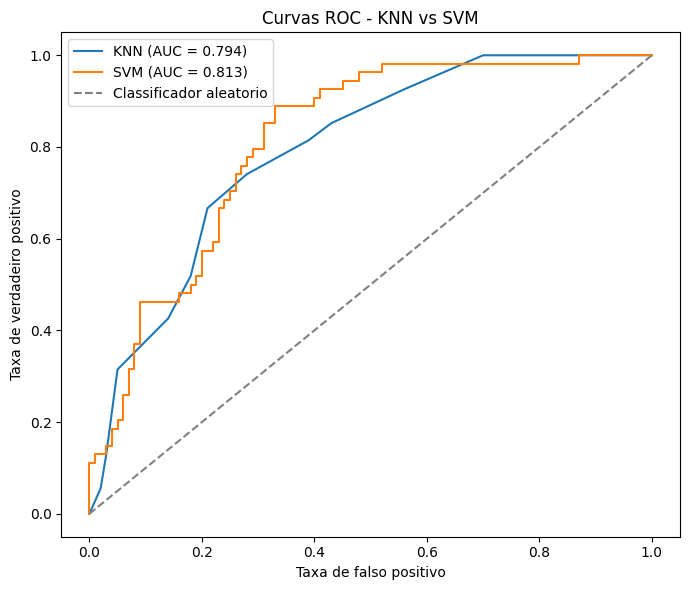

In [7]:
plot_confusion_matrix(prepared.y_test, knn_result.y_pred, "KNN")
plot_confusion_matrix(prepared.y_test, svm_result.y_pred, "SVM")
plot_knn_k_search(knn_result.grid_search)
plot_metrics_comparison(metrics_df)
plot_roc_curves([
    {
        "model_name": "KNN",
        "y_true": prepared.y_test,
        "y_proba": knn_result.y_proba,
        "metrics": knn_result.metrics,
    },
    {
        "model_name": "SVM",
        "y_true": prepared.y_test,
        "y_proba": svm_result.y_proba,
        "metrics": svm_result.metrics,
    },
])

## 6. Comparação dos resultados

O modelo com melhor desempenho geral foi o **KNN**, considerando F1-score e acurácia. O SVM apresentou ROC-AUC ligeiramente superior, indicando melhor capacidade de separar as classes.

- **KNN:** melhor k = 13
- **SVM:** kernel linear, C = 1, gamma = scale

## Conclusão

O projeto demonstra o fluxo completo de uma solução de IA: definição do problema, preparação dos dados, treinamento, avaliação e comparação entre modelos. Ambos os algoritmos classificam a presença de diabetes com desempenho razoável, com leve vantagem do KNN nas métricas principais.